# Rolex Watch Price Analysis - Part 3: Exploratory Data Analysis
## Visual and Statistical Exploration


## Libraries and settings


In [37]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.style.use('default')
sns.set_palette('Set2')

print(os.getcwd())


/Users/adisaljusi/repos/data_analytics/final


## 1. Load Cleaned Data


In [38]:
df = pd.read_csv('rolex_data_cleaned.csv', encoding='utf-8')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few records:")
df.head()


Dataset shape: (2373, 19)

First few records:


,web_scraper_order,brand_raw,model_raw,reference_number_raw,movement_type,condition_category,seller_type,case_material_clean,bracelet_material_clean,material_category,country,city,price,year,age,has_box,has_papers,has_complete_set,is_professional
0,1766787541-2,Rolex,Datejust 31,278274,Automatic,New,Professional dealer,Steel,Steel,Steel,Netherlands,Franeker,11415.0,2023.0,1.0,1,1,1,1
1,1766787544-3,Rolex,Cellini Danaos,4233,Manual,Fair,Professional dealer,Rose gold,Unknown,Rose Gold,United States of America,New York City,5248.0,2010.0,14.0,1,1,1,1
2,1766787546-4,Rolex,GMT-Master II,126720VTNR,Automatic,Very Good,Partner Certified Included,Steel,Steel,Steel,Netherlands,Franeker,14745.0,2024.0,0.0,1,1,1,0
3,1766787548-5,Rolex,Sea-Dweller,1665\n \n ...,Automatic,Very Good,Professional dealer,Steel,Steel,Steel,United States of America,Colorado,23009.0,1979.0,45.0,1,1,1,1
4,1766787550-6,Rolex,Explorer,124270\n \n ...,Automatic,Very Good,Partner Certified Included,Steel,Steel,Steel,Netherlands,Franeker,7132.0,2022.0,2.0,1,1,1,0


## 2. Descriptive Statistics


In [39]:
print("Summary Statistics for Numeric Variables:")
df.describe()


Summary Statistics for Numeric Variables:


,price,year,age,has_box,has_papers,has_complete_set,is_professional
count,2373.000000,1174.000000,1174.000000,2373.0,2373.0,2373.0,2373.000000
mean,13985.739149,2009.688245,14.311755,1.0,1.0,1.0,0.675516
std,13679.298647,15.535837,15.535837,0.0,0.0,0.0,0.468280
min,1294.000000,1942.000000,0.000000,1.0,1.0,1.0,0.000000
25%,6842.000000,2001.000000,2.000000,1.0,1.0,1.0,0.000000
50%,10559.000000,2015.000000,9.000000,1.0,1.0,1.0,1.000000
75%,15541.000000,2022.000000,23.000000,1.0,1.0,1.0,1.000000
max,205626.000000,2024.000000,82.000000,1.0,1.0,1.0,1.000000


In [40]:
print("Categorical Variables Summary:")
categorical_cols = ['condition_category', 'seller_type', 'material_category', 'movement_type']

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print("-" * 50)


Categorical Variables Summary:

condition_category:
condition_category
Very Good    1250
Good          497
New           345
Unknown       162
Fair          119
Name: count, dtype: int64
--------------------------------------------------

seller_type:
seller_type
Professional dealer           1603
Partner Certified Included     694
Private Seller                  76
Name: count, dtype: int64
--------------------------------------------------

material_category:
material_category
Steel          1454
Gold/Steel      302
Other           249
Yellow Gold     194
Rose Gold        85
White Gold       75
Platinum         14
Name: count, dtype: int64
--------------------------------------------------

movement_type:
movement_type
Automatic    2098
Unknown       239
Manual         31
Quartz          5
Name: count, dtype: int64
--------------------------------------------------


## 3. Price Distribution Analysis


### 3.1 Overall Price Distribution


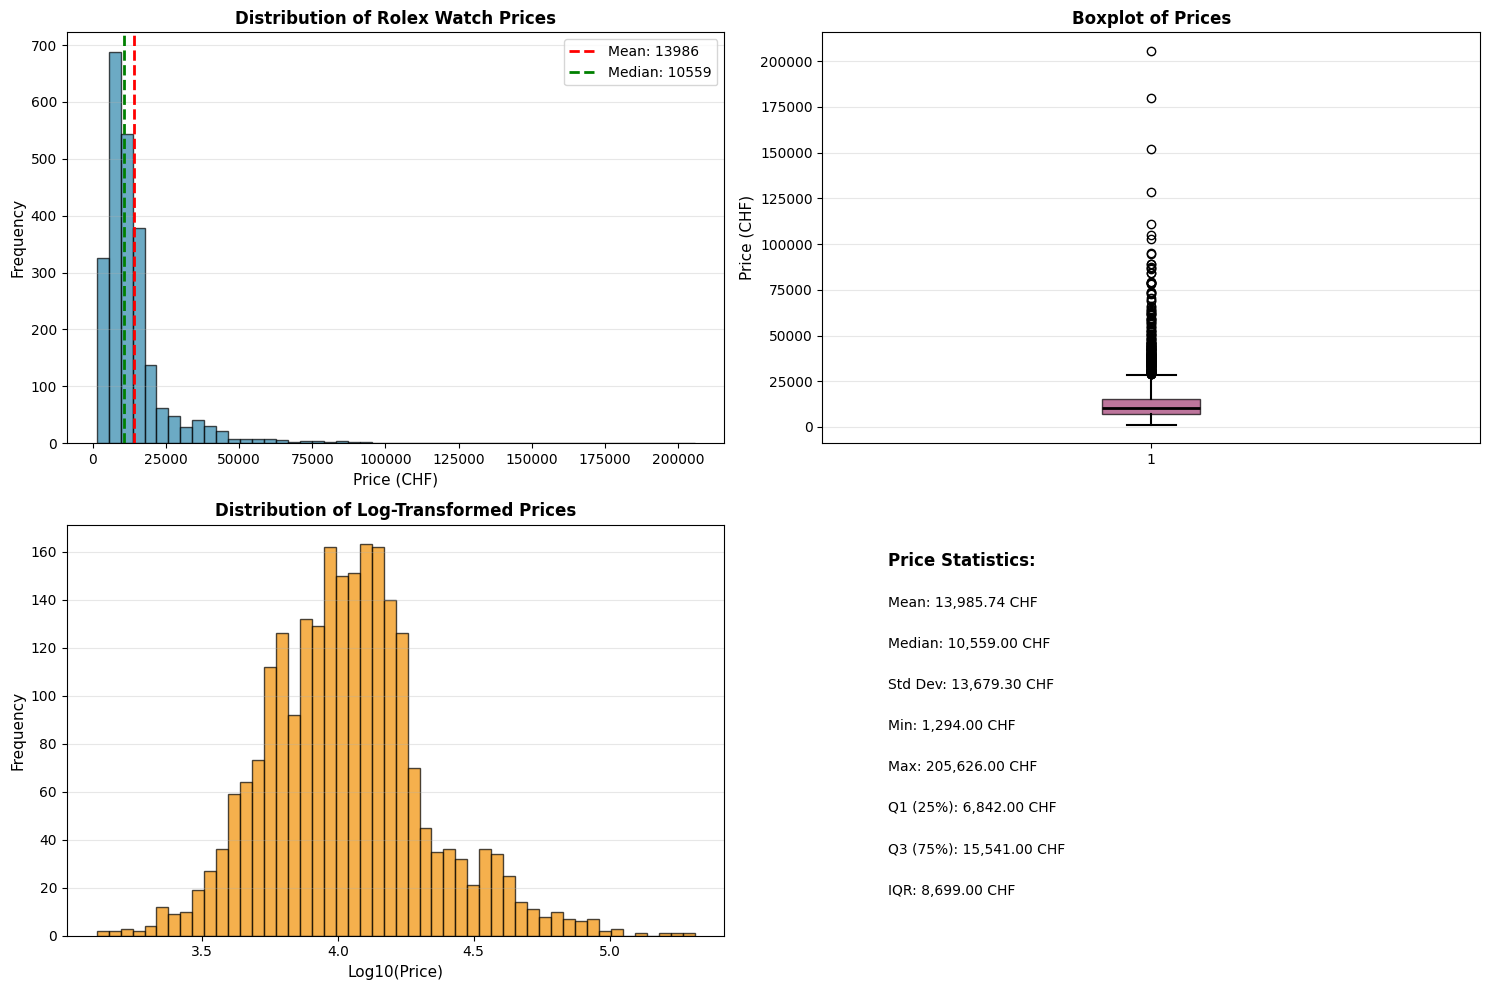

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].hist(df['price'], bins=50, color='#2E86AB', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['price'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["price"].mean():.0f}')
axes[0, 0].axvline(df['price'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["price"].median():.0f}')
axes[0, 0].set_xlabel('Price (CHF)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Distribution of Rolex Watch Prices', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

axes[0, 1].boxplot(df['price'], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='#A23B72', alpha=0.7),
                   medianprops=dict(color='black', linewidth=2),
                   whiskerprops=dict(linewidth=1.5),
                   capprops=dict(linewidth=1.5))
axes[0, 1].set_ylabel('Price (CHF)', fontsize=11)
axes[0, 1].set_title('Boxplot of Prices', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

log_prices = np.log10(df['price'])
axes[1, 0].hist(log_prices, bins=50, color='#F18F01', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Log10(Price)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Distribution of Log-Transformed Prices', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1
axes[1, 1].text(0.1, 0.9, f"Price Statistics:", fontsize=12, fontweight='bold', transform=axes[1, 1].transAxes)
axes[1, 1].text(0.1, 0.8, f"Mean: {df['price'].mean():,.2f} CHF", fontsize=10, transform=axes[1, 1].transAxes)
axes[1, 1].text(0.1, 0.7, f"Median: {df['price'].median():,.2f} CHF", fontsize=10, transform=axes[1, 1].transAxes)
axes[1, 1].text(0.1, 0.6, f"Std Dev: {df['price'].std():,.2f} CHF", fontsize=10, transform=axes[1, 1].transAxes)
axes[1, 1].text(0.1, 0.5, f"Min: {df['price'].min():,.2f} CHF", fontsize=10, transform=axes[1, 1].transAxes)
axes[1, 1].text(0.1, 0.4, f"Max: {df['price'].max():,.2f} CHF", fontsize=10, transform=axes[1, 1].transAxes)
axes[1, 1].text(0.1, 0.3, f"Q1 (25%): {q1:,.2f} CHF", fontsize=10, transform=axes[1, 1].transAxes)
axes[1, 1].text(0.1, 0.2, f"Q3 (75%): {q3:,.2f} CHF", fontsize=10, transform=axes[1, 1].transAxes)
axes[1, 1].text(0.1, 0.1, f"IQR: {iqr:,.2f} CHF", fontsize=10, transform=axes[1, 1].transAxes)
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()


### 3.2 Price by Condition


KeyError: 'boxes'

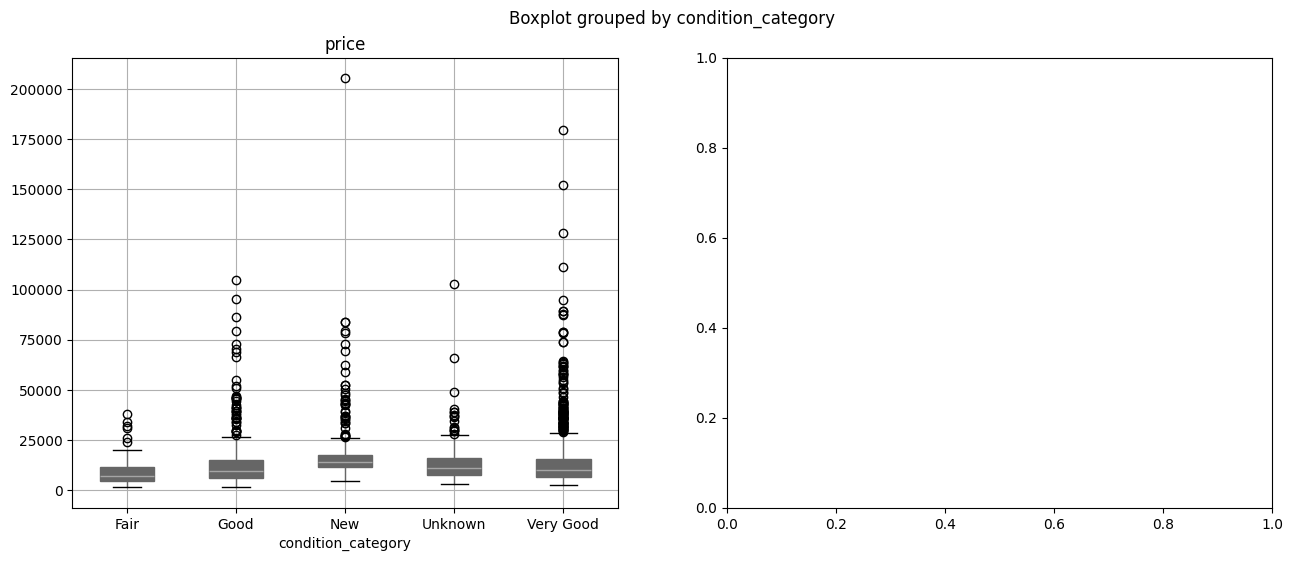

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

condition_order = ['New', 'Very Good', 'Good', 'Used', 'Fair', 'Incomplete', 'Unknown']
df_cond = df[df['condition_category'].isin(condition_order)]

bp = df_cond.boxplot(column='price', by='condition_category', ax=axes[0], patch_artist=True, return_type='dict')
for patch in bp['boxes']:
    patch.set_facecolor('#2E86AB')
    patch.set_alpha(0.7)
axes[0].set_xlabel('Condition', fontsize=11)
axes[0].set_ylabel('Price (CHF)', fontsize=11)
axes[0].set_title('Price Distribution by Condition', fontsize=12, fontweight='bold')
plt.suptitle('')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3)

avg_prices = df.groupby('condition_category')['price'].mean().sort_values(ascending=True)
axes[1].barh(avg_prices.index, avg_prices.values, color='#C73E1D', alpha=0.8)
axes[1].set_xlabel('Average Price (CHF)', fontsize=11)
axes[1].set_ylabel('Condition', fontsize=11)
axes[1].set_title('Average Price by Condition', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

for i, v in enumerate(avg_prices.values):
    axes[1].text(v, i, f' {v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


### 3.3 Price by Material Category


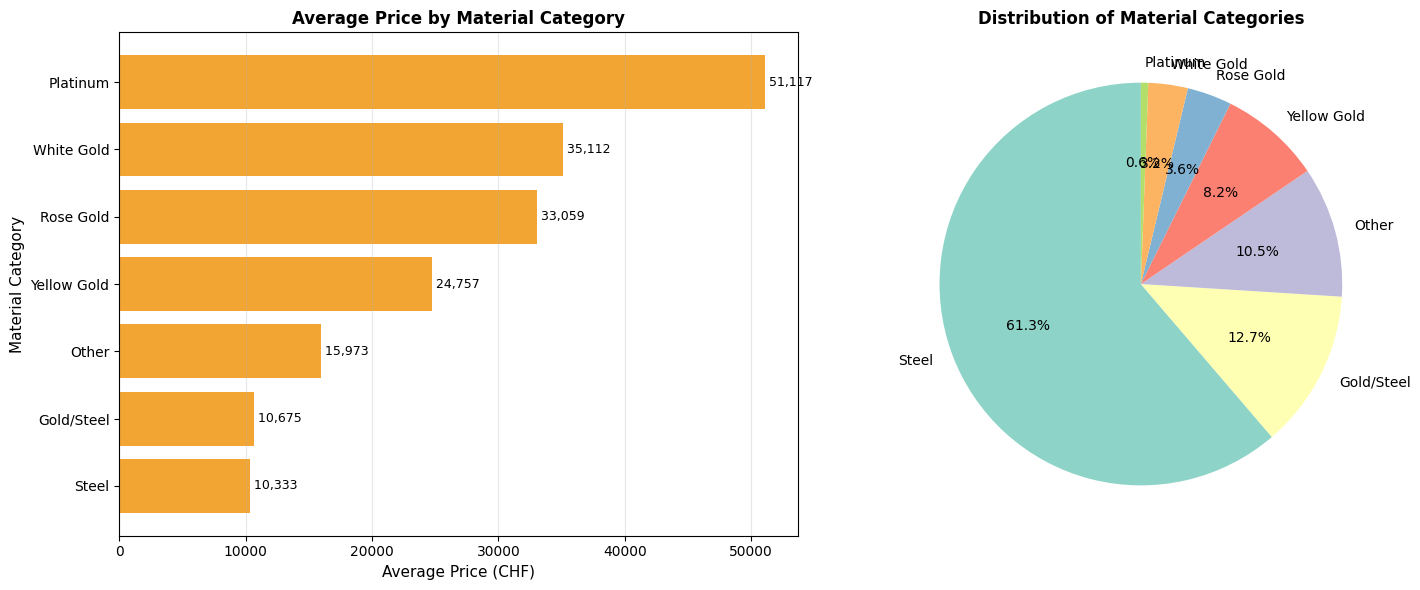

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

material_avg = df.groupby('material_category')['price'].agg(['mean', 'count']).sort_values('mean', ascending=True)
material_avg = material_avg[material_avg['count'] >= 10]

axes[0].barh(material_avg.index, material_avg['mean'], color='#F18F01', alpha=0.8)
axes[0].set_xlabel('Average Price (CHF)', fontsize=11)
axes[0].set_ylabel('Material Category', fontsize=11)
axes[0].set_title('Average Price by Material Category', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

for i, v in enumerate(material_avg['mean'].values):
    axes[0].text(v, i, f' {v:,.0f}', va='center', fontsize=9)

material_count = df['material_category'].value_counts()
colors_pie = plt.cm.Set3(range(len(material_count)))
axes[1].pie(material_count.values, labels=material_count.index, autopct='%1.1f%%',
            startangle=90, colors=colors_pie)
axes[1].set_title('Distribution of Material Categories', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


## 4. Geographic Analysis with Interactive Visualizations


### 4.1 Top Countries by Listing Count


In [51]:
country_stats = df.groupby('country').agg({
    'price': ['mean', 'median', 'count']
}).round(2)
country_stats.columns = ['avg_price', 'median_price', 'count']
country_stats = country_stats[country_stats['count'] >= 10].sort_values('count', ascending=False)

print("Top 20 Countries by Number of Listings:")
country_stats.head(20)


Top 20 Countries by Number of Listings:


,avg_price,median_price,count
country,,,
United States of America,14502.62,11111.0,935
Japan,11803.11,8963.5,758
Germany,15186.82,11367.0,96
Italy,16292.36,11181.5,96
Netherlands,12911.65,10679.5,94
United Kingdom,16074.34,11120.0,87
Hong Kong,17582.01,10953.5,78
France,16316.59,12257.0,37
Spain,16732.86,13441.5,36


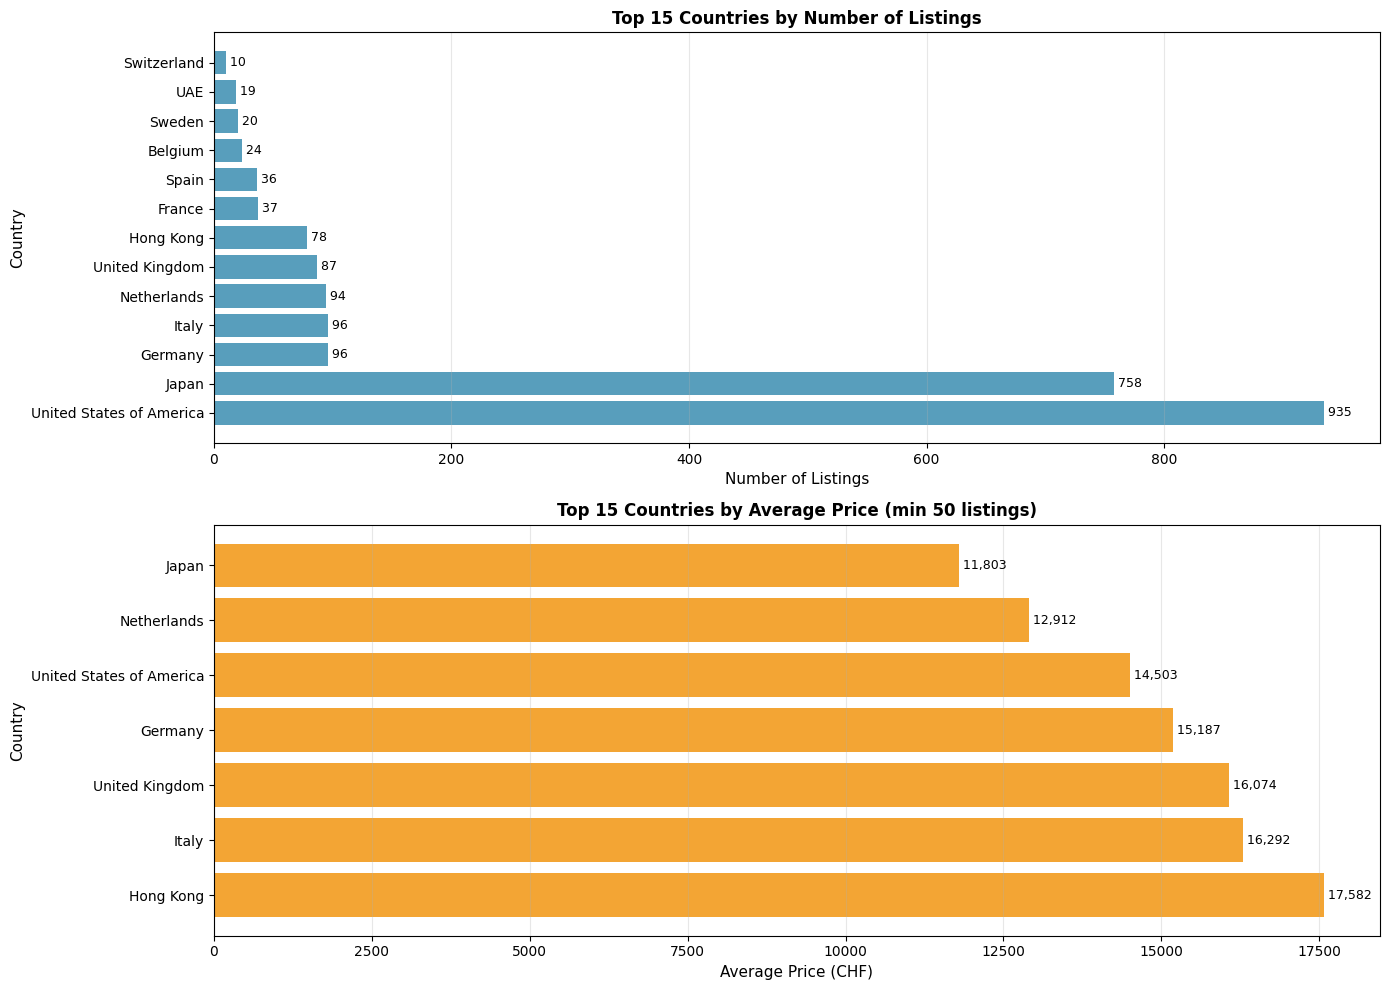

In [52]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

top_countries = country_stats.head(15)
axes[0].barh(range(len(top_countries)), top_countries['count'], color='#2E86AB', alpha=0.8)
axes[0].set_yticks(range(len(top_countries)))
axes[0].set_yticklabels(top_countries.index)
axes[0].set_xlabel('Number of Listings', fontsize=11)
axes[0].set_ylabel('Country', fontsize=11)
axes[0].set_title('Top 15 Countries by Number of Listings', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

for i, v in enumerate(top_countries['count'].values):
    axes[0].text(v, i, f' {int(v):,}', va='center', fontsize=9)

top_price_countries = country_stats[country_stats['count'] >= 50].sort_values('avg_price', ascending=False).head(15)
axes[1].barh(range(len(top_price_countries)), top_price_countries['avg_price'], color='#F18F01', alpha=0.8)
axes[1].set_yticks(range(len(top_price_countries)))
axes[1].set_yticklabels(top_price_countries.index)
axes[1].set_xlabel('Average Price (CHF)', fontsize=11)
axes[1].set_ylabel('Country', fontsize=11)
axes[1].set_title('Top 15 Countries by Average Price (min 50 listings)', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

for i, v in enumerate(top_price_countries['avg_price'].values):
    axes[1].text(v, i, f' {v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


### 4.2 Interactive Geographic Visualization with Plotly

This creates an interactive world map showing average Rolex prices by country.
**This satisfies the "Integration and visualization of geographical data" requirement for additional points.**


In [53]:
# Prepare data for geographic visualization
geo_data = df.groupby('country').agg({
    'price': ['mean', 'median', 'count'],
    'web_scraper_order': 'count'
}).reset_index()
geo_data.columns = ['country', 'avg_price', 'median_price', 'price_count', 'total_listings']
geo_data = geo_data[geo_data['total_listings'] >= 5]

# Create interactive choropleth map
fig = px.choropleth(geo_data,
                     locations='country',
                     locationmode='country names',
                     color='avg_price',
                     hover_name='country',
                     hover_data={
                         'avg_price': ':,.0f',
                         'median_price': ':,.0f',
                         'total_listings': ':,d',
                         'country': False
                     },
                     color_continuous_scale='Viridis',
                     title='Average Rolex Prices by Country (Interactive Map)',
                     labels={'avg_price': 'Avg Price (CHF)'})

fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth'
    ),
    height=600,
    title_font_size=16
)

fig.show()


In [54]:
# Create bubble map showing listing volume and prices
fig2 = px.scatter_geo(geo_data,
                       locations='country',
                       locationmode='country names',
                       color='avg_price',
                       size='total_listings',
                       hover_name='country',
                       hover_data={
                           'avg_price': ':,.0f',
                           'total_listings': ':,d',
                           'country': False
                       },
                       color_continuous_scale='RdYlGn_r',
                       size_max=50,
                       title='Rolex Market: Listing Volume and Average Prices by Country',
                       labels={'avg_price': 'Avg Price (CHF)', 'total_listings': 'Listings'})

fig2.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth'
    ),
    height=600
)

fig2.show()


## 5. Documentation Impact Analysis


In [55]:
doc_categories = []
for idx, row in df.iterrows():
    if row['has_complete_set'] == 1:
        doc_categories.append('Complete Set')
    elif row['has_box'] == 1 and row['has_papers'] == 0:
        doc_categories.append('Box Only')
    elif row['has_box'] == 0 and row['has_papers'] == 1:
        doc_categories.append('Papers Only')
    else:
        doc_categories.append('No Documentation')

df['documentation'] = doc_categories

doc_stats = df.groupby('documentation')['price'].agg(['mean', 'median', 'count']).round(2)
doc_stats = doc_stats.sort_values('mean', ascending=False)

print("Price Statistics by Documentation:")
doc_stats


Price Statistics by Documentation:


,mean,median,count
documentation,,,
Complete Set,13985.74,10559.0,2373


KeyError: 'boxes'

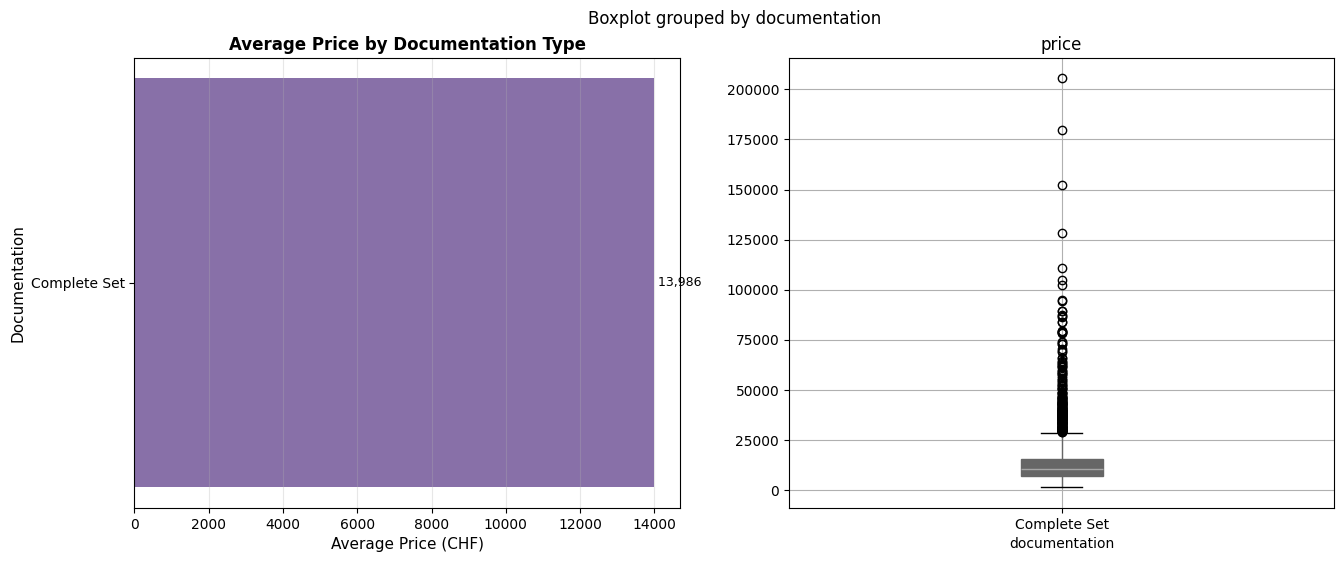

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(doc_stats.index, doc_stats['mean'], color='#6A4C93', alpha=0.8)
axes[0].set_xlabel('Average Price (CHF)', fontsize=11)
axes[0].set_ylabel('Documentation', fontsize=11)
axes[0].set_title('Average Price by Documentation Type', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

for i, v in enumerate(doc_stats['mean'].values):
    axes[0].text(v, i, f' {v:,.0f}', va='center', fontsize=9)

bp = df.boxplot(column='price', by='documentation', ax=axes[1], patch_artist=True, return_type='dict')
for patch in bp['boxes']:
    patch.set_facecolor('#A23B72')
    patch.set_alpha(0.7)
axes[1].set_xlabel('Documentation', fontsize=11)
axes[1].set_ylabel('Price (CHF)', fontsize=11)
axes[1].set_title('Price Distribution by Documentation', fontsize=12, fontweight='bold')
plt.suptitle('')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Interactive Plotly Visualizations


In [57]:
# Interactive price distribution
fig = px.histogram(df, x='price', nbins=50,
                   title='Interactive Price Distribution',
                   labels={'price': 'Price (CHF)'},
                   color_discrete_sequence=['#2E86AB'])
fig.update_layout(showlegend=False, height=500)
fig.show()


In [58]:
# Interactive scatter: Price vs Age by Material
df_plot = df.dropna(subset=['age'])

fig = px.scatter(df_plot, x='age', y='price',
                 color='material_category',
                 hover_data=['model_raw', 'condition_category', 'country'],
                 title='Price vs Age by Material Category (Interactive)',
                 labels={'age': 'Age (years)', 'price': 'Price (CHF)'},
                 opacity=0.6)
fig.update_layout(height=600)
fig.show()


In [59]:
# Interactive box plot
fig = px.box(df, x='condition_category', y='price',
             title='Price Distribution by Condition (Interactive)',
             labels={'condition_category': 'Condition', 'price': 'Price (CHF)'},
             color='condition_category')
fig.update_layout(showlegend=False, height=600)
fig.show()


## 7. Summary of Key Findings


In [60]:
print("="*70)
print("KEY FINDINGS FROM EXPLORATORY DATA ANALYSIS")
print("="*70)

print("\n1. PRICE DISTRIBUTION:")
print(f"   - Average price: {df['price'].mean():,.2f} CHF")
print(f"   - Median price: {df['price'].median():,.2f} CHF")
print(f"   - Price range: {df['price'].min():,.2f} - {df['price'].max():,.2f} CHF")
print(f"   - The distribution is right-skewed (mean > median)")

print("\n2. CONDITION IMPACT:")
new_price = df[df['condition_category'] == 'New']['price'].mean()
used_price = df[df['condition_category'] == 'Used']['price'].mean()
print(f"   - New watches average: {new_price:,.2f} CHF")
print(f"   - Used watches average: {used_price:,.2f} CHF")
if not np.isnan(new_price) and not np.isnan(used_price) and used_price > 0:
    print(f"   - Price premium for new: {((new_price/used_price - 1) * 100):.1f}%")

print("\n3. MATERIAL IMPACT:")
steel_price = df[df['material_category'] == 'Steel']['price'].mean()
gold_price = df[df['material_category'] == 'Yellow Gold']['price'].mean()
if not np.isnan(steel_price):
    print(f"   - Steel watches average: {steel_price:,.2f} CHF")
if not np.isnan(gold_price):
    print(f"   - Yellow Gold watches average: {gold_price:,.2f} CHF")
if not np.isnan(steel_price) and not np.isnan(gold_price) and steel_price > 0:
    print(f"   - Gold premium over steel: {((gold_price/steel_price - 1) * 100):.1f}%")

print("\n4. DOCUMENTATION IMPACT:")
complete_price = df[df['has_complete_set'] == 1]['price'].mean()
no_doc_price = df[(df['has_box'] == 0) & (df['has_papers'] == 0)]['price'].mean()
if not np.isnan(complete_price):
    print(f"   - With complete set: {complete_price:,.2f} CHF")
if not np.isnan(no_doc_price):
    print(f"   - Without documentation: {no_doc_price:,.2f} CHF")
if not np.isnan(complete_price) and not np.isnan(no_doc_price) and no_doc_price > 0:
    print(f"   - Premium for complete set: {((complete_price/no_doc_price - 1) * 100):.1f}%")

print("\n5. GEOGRAPHIC DISTRIBUTION:")
top_country = df['country'].value_counts().index[0]
top_count = df['country'].value_counts().values[0]
print(f"   - Top country: {top_country} ({top_count:,} listings)")
print(f"   - Total countries: {df['country'].nunique()}")

print("\n" + "="*70)


KEY FINDINGS FROM EXPLORATORY DATA ANALYSIS

1. PRICE DISTRIBUTION:
   - Average price: 13,985.74 CHF
   - Median price: 10,559.00 CHF
   - Price range: 1,294.00 - 205,626.00 CHF
   - The distribution is right-skewed (mean > median)

2. CONDITION IMPACT:
   - New watches average: 17,768.77 CHF
   - Used watches average: nan CHF

3. MATERIAL IMPACT:
   - Steel watches average: 10,333.50 CHF
   - Yellow Gold watches average: 24,757.38 CHF
   - Gold premium over steel: 139.6%

4. DOCUMENTATION IMPACT:
   - With complete set: 13,985.74 CHF

5. GEOGRAPHIC DISTRIBUTION:
   - Top country: United States of America (935 listings)
   - Total countries: 35



## Jupyter notebook --footer info-- (please always provide this at the end of each submitted notebook)


In [61]:
import os
import platform
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Darwin | 25.2.0
Datetime: 2025-12-28 11:35:30
Python Version: 3.11.13
-----------------------------------
